# Category: Housing
We will conduct our exploratory data analysis for this category using selected variables. Then we will create a scoring system using PCA. Finally, we will validate our results using real migration data.

# Setup

In [ ]:
import os
import sys
import math
import json
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("housing_data_wide.csv")

In [ ]:
df

,FIPS_5digit,State_FIPS,County_FIPS,State,County,Rent_2BR_Monthly_2020,Rent_2BR_Monthly_2021,Rent_2BR_Monthly_2022,Rent_2BR_Monthly_2023,Rent_2BR_Monthly_2024,Rent_2BR_Monthly_2025,Rent_2BR_Monthly_2026,Rent_2BR_Annual_2020,Rent_2BR_Annual_2021,Rent_2BR_Annual_2022,Rent_2BR_Annual_2023,Rent_2BR_Annual_2024,Rent_2BR_Annual_2025,Rent_2BR_Annual_2026,Median_HH_Income_2020,Median_HH_Income_2021,Median_HH_Income_2022,Median_HH_Income_2023,Median_HH_Income_2024,Median_HH_Income_2025,Median_HH_Income_2026,Housing_Affordability_Pct_2020,Housing_Affordability_Pct_2021,Housing_Affordability_Pct_2022,Housing_Affordability_Pct_2023,Housing_Affordability_Pct_2024,Housing_Affordability_Pct_2025,Housing_Affordability_Pct_2026,Severe_Housing_Cost_Burden_2020,Severe_Housing_Cost_Burden_2021,Severe_Housing_Cost_Burden_2022,Severe_Housing_Cost_Burden_2023,Severe_Housing_Cost_Burden_2024,Severe_Housing_Cost_Burden_2025,Severe_Housing_Cost_Burden_2026,Severe_Housing_Problems_2020,Severe_Housing_Problems_2021,Severe_Housing_Problems_2022,Severe_Housing_Problems_2023,Severe_Housing_Problems_2024,Severe_Housing_Problems_2025,Severe_Housing_Problems_2026,Rent_2BR_Monthly_Avg,Rent_2BR_Annual_Avg,Median_HH_Income_Avg,Housing_Affordability_Pct_Avg,Severe_Housing_Cost_Burden_Avg,Severe_Housing_Problems_Avg
0,1001,1,1,AL,Autauga County,876.0,972.0,976.0,1055.0,1170.0,1147.0,1107.0,10512.0,11664.0,11712.0,12660.0,14040.0,13764.0,13284.0,68857.0,68857.0,68857.0,68857.0,68857.0,68857.0,68857.0,15.27,16.94,17.01,18.39,20.39,19.99,19.29,0.098233,0.098233,0.098233,0.098233,0.098233,0.098233,0.098233,0.135209,0.135209,0.135209,0.135209,0.135209,0.135209,0.135209,1043.29,12519.43,68857.0,18.18,0.10,0.14
1,1003,1,3,AL,Baldwin County,992.0,1054.0,1149.0,1328.0,1458.0,1381.0,1509.0,11904.0,12648.0,13788.0,15936.0,17496.0,16572.0,18108.0,74248.0,74248.0,74248.0,74248.0,74248.0,74248.0,74248.0,16.03,17.03,18.57,21.46,23.56,22.32,24.39,0.115515,0.115515,0.115515,0.115515,0.115515,0.115515,0.115515,0.119681,0.119681,0.119681,0.119681,0.119681,0.119681,0.119681,1267.29,15207.43,74248.0,20.48,0.12,0.12
2,1005,1,5,AL,Barbour County,674.0,689.0,739.0,784.0,881.0,778.0,787.0,8088.0,8268.0,8868.0,9408.0,10572.0,9336.0,9444.0,45298.0,45298.0,45298.0,45298.0,45298.0,45298.0,45298.0,17.86,18.25,19.58,20.77,23.34,20.61,20.85,0.106660,0.106660,0.106660,0.106660,0.106660,0.106660,0.106660,0.138064,0.138064,0.138064,0.138064,0.138064,0.138064,0.138064,761.71,9140.57,45298.0,20.18,0.11,0.14
3,1007,1,7,AL,Bibb County,1073.0,1093.0,1029.0,1178.0,1361.0,1389.0,1387.0,12876.0,13116.0,12348.0,14136.0,16332.0,16668.0,16644.0,56025.0,56025.0,56025.0,56025.0,56025.0,56025.0,56025.0,22.98,23.41,22.04,25.23,29.15,29.75,29.71,0.110070,0.110070,0.110070,0.110070,0.110070,0.110070,0.110070,0.119266,0.119266,0.119266,0.119266,0.119266,0.119266,0.119266,1215.71,14588.57,56025.0,26.04,0.11,0.12
4,1009,1,9,AL,Blount County,1073.0,1093.0,1029.0,1178.0,1361.0,1389.0,1387.0,12876.0,13116.0,12348.0,14136.0,16332.0,16668.0,16644.0,64962.0,64962.0,64962.0,64962.0,64962.0,64962.0,64962.0,19.82,20.19,19.01,21.76,25.14,25.66,25.62,0.093673,0.093673,0.093673,0.093673,0.093673,0.093673,0.093673,0.102582,0.102582,0.102582,0.102582,0.102582,0.102582,0.102582,1215.71,14588.57,64962.0,22.46,0.09,0.10


## Initial profiling

We have the following variables according to years.

| Variable | Explanation |
| --- | --- |
| Rent_2BR_Monthly | HUD 50th percentile monthly rent for a 2-bedroom unit (dollars). |
| Rent_2BR_Annual | Annual 2-bedroom rent (Rent_2BR_Monthly × 12, in dollars). |
| Median_HH_Income | County median household income in dollars (2025 County Health Rankings). |
| Housing_Affordability_Pct | Annual 2-bedroom rent as a % of median household income. Values >30% indicate cost-burdened households. |
| Severe_Housing_Cost_Burden | Share of households spending ≥50% of income on housing (proportion 0–1). |
| Severe_Housing_Problems | Share of households with at least one severe housing problem: overcrowding, high costs, lack of kitchen or plumbing (proportion 0–1). |

In [ ]:
print('Rows:', len(df), 'Columns:', df.shape[1])
display(df.drop(columns=['FIPS_5digit','State_FIPS','County_FIPS','State','County']).describe(include='all').T)

Rows: 3157 Columns: 53


,count,mean,std,min,25%,50%,75%,max
Rent_2BR_Monthly_2020,3143.0,882.582564,283.047960,612.00000,714.000000,793.000000,950.000000,3477.000000
Rent_2BR_Monthly_2021,3143.0,910.342348,296.255327,634.00000,734.000000,816.000000,977.500000,3700.000000
Rent_2BR_Monthly_2022,3141.0,942.822031,307.093366,649.00000,757.000000,847.000000,1014.000000,3486.000000
Rent_2BR_Monthly_2023,3144.0,1046.711514,328.266405,767.00000,853.000000,921.500000,1109.000000,3590.000000
Rent_2BR_Monthly_2024,3144.0,1150.605598,385.009305,797.00000,905.000000,1013.000000,1247.000000,4222.000000
Rent_2BR_Monthly_2025,3144.0,1194.890585,408.609538,772.00000,933.000000,1039.500000,1316.000000,4398.000000
Rent_2BR_Monthly_2026,3145.0,1245.946264,422.472469,776.00000,973.000000,1097.000000,1382.000000,4388.000000
Rent_2BR_Annual_2020,3143.0,10590.990773,3396.575523,7344.00000,8568.000000,9516.000000,11400.000000,41724.000000
Rent_2BR_Annual_2021,3143.0,10924.108177,3555.063926,7608.00000,8808.000000,9792.000000,11730.000000,44400.000000
Rent_2BR_Annual_2022,3141.0,11313.864374,3685.120393,7788.00000,9084.000000,10164.000000,12168.000000,41832.000000


## Missingness analysis

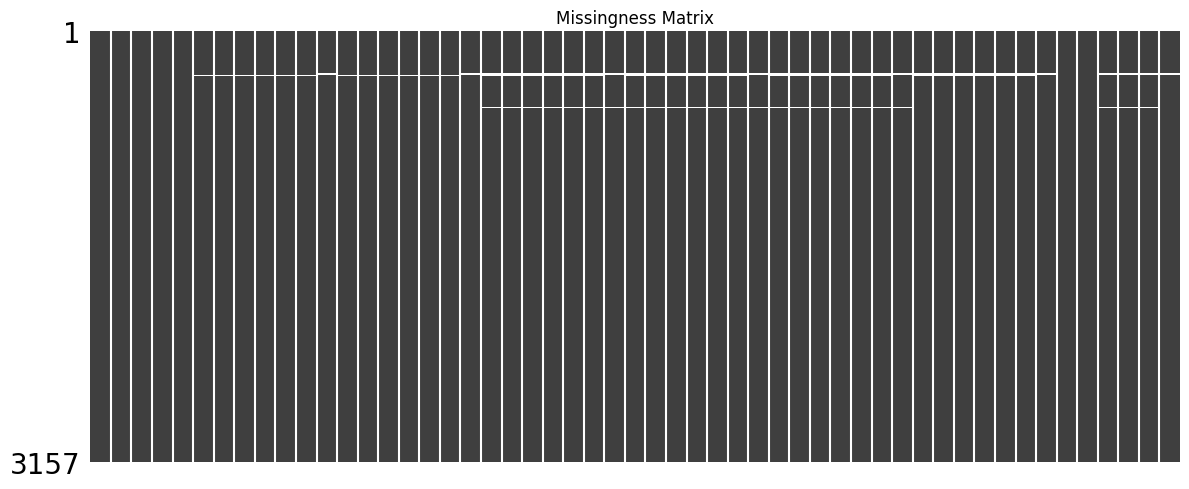

In [ ]:
import missingno as msno
msno.matrix(df)
plt.show()

We notice that some rows have missing data, mainly counties that could not be matched to the analytic dataset for income and housing burden metrics.

In [ ]:
missing_fraction = df.isna().mean(axis=1)
rows_missing_data = df[missing_fraction > 0.90]
print('Total number of counties missing more than 90% of data is ' + str(len(rows_missing_data)))
display(rows_missing_data[['FIPS_5digit', 'State', 'County']])

Total number of counties missing more than 90% of data is 2


,FIPS_5digit,State,County
95,2261,NaN,Valdez-Cordova Census Area
1524,29056,NaN,Sullivan part


We note any counties that could not be matched to the analytic data for income and housing burden variables.

In [ ]:
missing_fraction_cols = df.isna().mean(axis=0)
worst_col = missing_fraction_cols.idxmax()
print("Column with most missing data:", worst_col)
print("Missing percent:", missing_fraction_cols[worst_col] * 100)
print("Missing count:", df[worst_col].isna().sum())

Column with most missing data: Severe_Housing_Cost_Burden_2020
Missing percent: 0.95
Missing count: 30


We will keep this variable since the missing percentage is not high enough to justify dropping the column.

In [ ]:
df_new = df[missing_fraction <= 0.90]

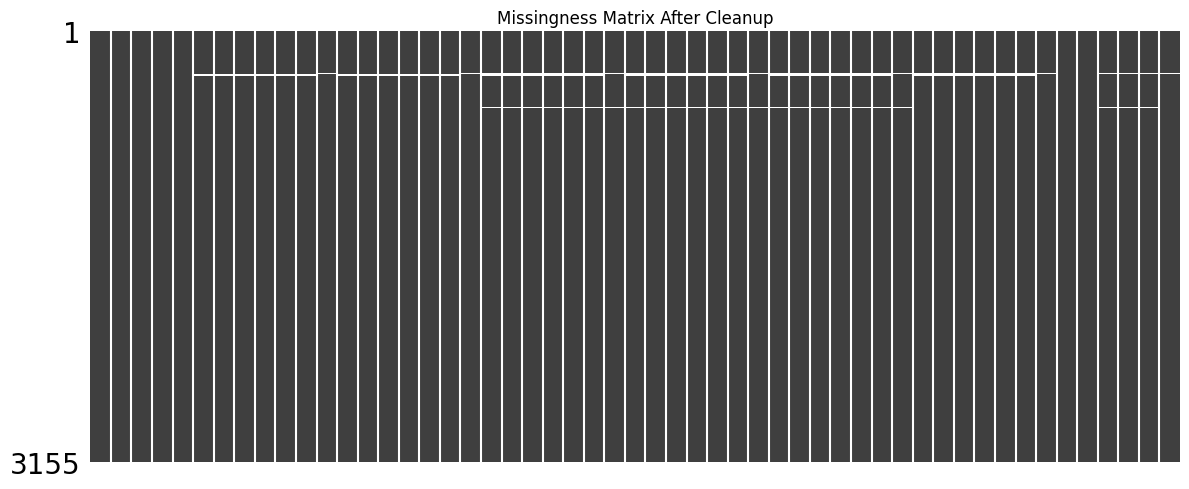

In [ ]:
msno.matrix(df_new)
plt.show()

## Ranges and Impossible Values
Now, let's carefully check the ranges and possible outliers for our variables.

In [ ]:
rent_2br_monthly_cols = [
    "Rent_2BR_Monthly_2020",
    "Rent_2BR_Monthly_2021",
    "Rent_2BR_Monthly_2022",
    "Rent_2BR_Monthly_2023",
    "Rent_2BR_Monthly_2024",
    "Rent_2BR_Monthly_2025",
    "Rent_2BR_Monthly_2026"
]
bad = df_new[df_new[rent_2br_monthly_cols].lt(0).any(axis=1)]
print("Number of impossible Rent_2BR_Monthly values (negative):", len(bad))
if len(bad) == 0:
    print("No impossible values found.")
else:
    display(bad[['FIPS_5digit', 'State', 'County'] + rent_2br_monthly_cols])

Number of impossible Rent_2BR_Monthly values (negative): 0
No impossible values found.


In [ ]:
median_hh_income_cols = [
    "Median_HH_Income_2020",
    "Median_HH_Income_2021",
    "Median_HH_Income_2022",
    "Median_HH_Income_2023",
    "Median_HH_Income_2024",
    "Median_HH_Income_2025",
    "Median_HH_Income_2026"
]
bad = df_new[df_new[median_hh_income_cols].lt(0).any(axis=1)]
print("Number of impossible Median_HH_Income values (negative):", len(bad))
if len(bad) == 0:
    print("No impossible values found.")
else:
    display(bad[['FIPS_5digit', 'State', 'County'] + median_hh_income_cols])

Number of impossible Median_HH_Income values (negative): 0
No impossible values found.


In [ ]:
housing_affordability_pct_cols = [
    "Housing_Affordability_Pct_2020",
    "Housing_Affordability_Pct_2021",
    "Housing_Affordability_Pct_2022",
    "Housing_Affordability_Pct_2023",
    "Housing_Affordability_Pct_2024",
    "Housing_Affordability_Pct_2025",
    "Housing_Affordability_Pct_2026"
]
bad = df_new[df_new[housing_affordability_pct_cols].lt(0).any(axis=1)]
print("Number of impossible Housing_Affordability_Pct values (negative):", len(bad))
if len(bad) == 0:
    print("No impossible values found.")
else:
    display(bad[['FIPS_5digit', 'State', 'County'] + housing_affordability_pct_cols])

Number of impossible Housing_Affordability_Pct values (negative): 0
No impossible values found.


In [ ]:
severe_housing_cost_burden_cols = [
    "Severe_Housing_Cost_Burden_2020",
    "Severe_Housing_Cost_Burden_2021",
    "Severe_Housing_Cost_Burden_2022",
    "Severe_Housing_Cost_Burden_2023",
    "Severe_Housing_Cost_Burden_2024",
    "Severe_Housing_Cost_Burden_2025",
    "Severe_Housing_Cost_Burden_2026"
]
bad = df_new[
    (df_new[severe_housing_cost_burden_cols].lt(0).any(axis=1)) |
    (df_new[severe_housing_cost_burden_cols].gt(1).any(axis=1))
]
print("Number of impossible Severe_Housing_Cost_Burden values (outside [0,1]):", len(bad))
if len(bad) == 0:
    print("No impossible values found.")
else:
    display(bad[['FIPS_5digit', 'State', 'County'] + severe_housing_cost_burden_cols])

Number of impossible Severe_Housing_Cost_Burden values (outside [0,1]): 0
No impossible values found.


In [ ]:
severe_housing_problems_cols = [
    "Severe_Housing_Problems_2020",
    "Severe_Housing_Problems_2021",
    "Severe_Housing_Problems_2022",
    "Severe_Housing_Problems_2023",
    "Severe_Housing_Problems_2024",
    "Severe_Housing_Problems_2025",
    "Severe_Housing_Problems_2026"
]
bad = df_new[
    (df_new[severe_housing_problems_cols].lt(0).any(axis=1)) |
    (df_new[severe_housing_problems_cols].gt(1).any(axis=1))
]
print("Number of impossible Severe_Housing_Problems values (outside [0,1]):", len(bad))
if len(bad) == 0:
    print("No impossible values found.")
else:
    display(bad[['FIPS_5digit', 'State', 'County'] + severe_housing_problems_cols])

Number of impossible Severe_Housing_Problems values (outside [0,1]): 0
No impossible values found.


## Duplicates

In [ ]:
dup_rows = df_new.duplicated(keep=False)
print('Duplicate rows:', dup_rows.sum())

Duplicate rows: 0


## Profiling After Cleanup

In [ ]:
display(df_new[rent_monthly_cols].describe().T)
display(df_new[income_cols].describe().T)
display(df_new[afford_cols].describe().T)
display(df_new[cost_burden_cols].describe().T)
display(df_new[housing_prob_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Rent_2BR_Monthly_2020,3143.0,882.582564,283.047960,612.0,714.0,793.0,950.0,3477.0
Rent_2BR_Monthly_2021,3143.0,910.342348,296.255327,634.0,734.0,816.0,977.5,3700.0
Rent_2BR_Monthly_2022,3141.0,942.822031,307.093366,649.0,757.0,847.0,1014.0,3486.0
Rent_2BR_Monthly_2023,3144.0,1046.711514,328.266405,767.0,853.0,921.5,1109.0,3590.0
Rent_2BR_Monthly_2024,3144.0,1150.605598,385.009305,797.0,905.0,1013.0,1247.0,4222.0
Rent_2BR_Monthly_2025,3144.0,1194.890585,408.609538,772.0,933.0,1039.5,1316.0,4398.0
Rent_2BR_Monthly_2026,3145.0,1245.946264,422.472469,776.0,973.0,1097.0,1382.0,4388.0


,count,mean,std,min,25%,50%,75%,max
Median_HH_Income_2020,3132.0,65474.661239,16490.121825,28579.0,54596.50,62744.0,73010.0,173655.0
Median_HH_Income_2021,3132.0,65474.661239,16490.121825,28579.0,54596.50,62744.0,73010.0,173655.0
Median_HH_Income_2022,3132.0,65474.661239,16490.121825,28579.0,54596.50,62744.0,73010.0,173655.0
Median_HH_Income_2023,3134.0,65485.293874,16493.521258,28579.0,54601.75,62771.0,73022.0,173655.0
Median_HH_Income_2024,3134.0,65485.293874,16493.521258,28579.0,54601.75,62771.0,73022.0,173655.0
Median_HH_Income_2025,3134.0,65485.293874,16493.521258,28579.0,54601.75,62771.0,73022.0,173655.0
Median_HH_Income_2026,3143.0,65561.641425,16543.495767,28579.0,54616.00,62851.0,73073.5,173655.0


,count,mean,std,min,25%,50%,75%,max
Housing_Affordability_Pct_2020,3132.0,16.313068,3.270544,9.23,14.1875,15.800,17.900,54.61
Housing_Affordability_Pct_2021,3132.0,16.813732,3.403008,9.17,14.5875,16.290,18.490,57.91
Housing_Affordability_Pct_2022,3132.0,17.412676,3.564649,9.25,15.1000,16.855,19.080,64.10
Housing_Affordability_Pct_2023,3134.0,19.373108,3.929228,10.46,16.7825,18.740,21.230,67.15
Housing_Affordability_Pct_2024,3134.0,21.244094,4.717967,11.22,18.0925,20.640,23.520,75.41
Housing_Affordability_Pct_2025,3134.0,22.024821,4.986270,11.56,18.5800,21.285,24.520,72.80
Housing_Affordability_Pct_2026,3143.0,22.950576,5.078791,12.00,19.4400,22.180,25.635,81.78


,count,mean,std,min,25%,50%,75%,max
Severe_Housing_Cost_Burden_2020,3127.0,0.110982,0.035477,0.01355,0.087441,0.106635,0.129364,0.368304
Severe_Housing_Cost_Burden_2021,3127.0,0.110982,0.035477,0.01355,0.087441,0.106635,0.129364,0.368304
Severe_Housing_Cost_Burden_2022,3127.0,0.110982,0.035477,0.01355,0.087441,0.106635,0.129364,0.368304
Severe_Housing_Cost_Burden_2023,3129.0,0.110947,0.035493,0.01355,0.087344,0.106620,0.129356,0.368304
Severe_Housing_Cost_Burden_2024,3129.0,0.110947,0.035493,0.01355,0.087344,0.106620,0.129356,0.368304
Severe_Housing_Cost_Burden_2025,3129.0,0.110947,0.035493,0.01355,0.087344,0.106620,0.129356,0.368304
Severe_Housing_Cost_Burden_2026,3138.0,0.111076,0.035552,0.01355,0.087456,0.106669,0.129546,0.368304


,count,mean,std,min,25%,50%,75%,max
Severe_Housing_Problems_2020,3133.0,0.128060,0.044214,0.0,0.100868,0.121704,0.148148,0.61157
Severe_Housing_Problems_2021,3133.0,0.128060,0.044214,0.0,0.100868,0.121704,0.148148,0.61157
Severe_Housing_Problems_2022,3133.0,0.128060,0.044214,0.0,0.100868,0.121704,0.148148,0.61157
Severe_Housing_Problems_2023,3135.0,0.128076,0.044230,0.0,0.100865,0.121704,0.148151,0.61157
Severe_Housing_Problems_2024,3135.0,0.128076,0.044230,0.0,0.100865,0.121704,0.148151,0.61157
Severe_Housing_Problems_2025,3135.0,0.128076,0.044230,0.0,0.100865,0.121704,0.148151,0.61157
Severe_Housing_Problems_2026,3144.0,0.128186,0.044246,0.0,0.100900,0.121759,0.148240,0.61157


## Correlation Between Variables

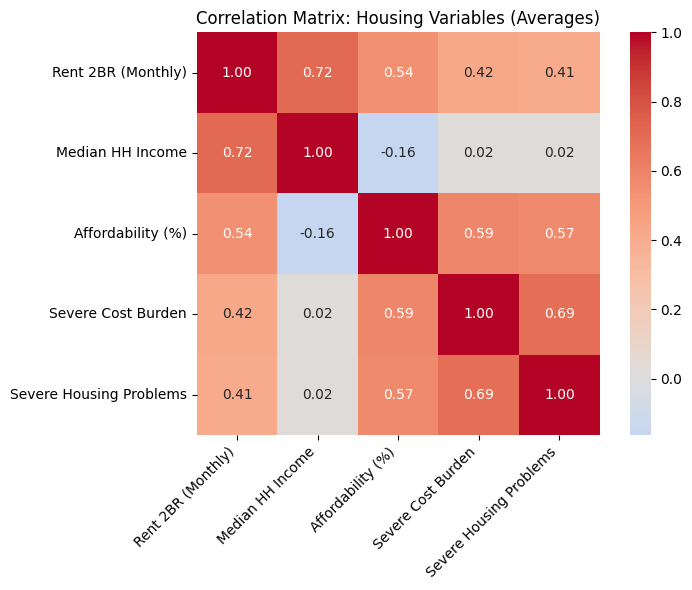

In [ ]:
import seaborn as sns
avg_cols = ['Rent_2BR_Monthly_Avg','Median_HH_Income_Avg','Housing_Affordability_Pct_Avg',
            'Severe_Housing_Cost_Burden_Avg','Severe_Housing_Problems_Avg']
short_names = {
    'Rent_2BR_Monthly_Avg':           'Rent 2BR (Monthly)',
    'Median_HH_Income_Avg':           'Median HH Income',
    'Housing_Affordability_Pct_Avg':  'Affordability (%)',
    'Severe_Housing_Cost_Burden_Avg': 'Severe Cost Burden',
    'Severe_Housing_Problems_Avg':    'Severe Housing Problems',
}
corr = df_new[avg_cols].corr().rename(index=short_names, columns=short_names)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix: Housing Variables (Averages)")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0); plt.tight_layout()
plt.show()

The strongest relationship is between Housing Affordability Pct and Severe Housing Cost Burden, which makes sense since both measure rent burden relative to income — one as a continuous percentage and the other as a threshold proportion.

Median HH Income is negatively correlated with both Affordability Pct and Severe Cost Burden, reflecting that higher-income counties tend to have lower housing cost burdens relative to their earnings, despite potentially higher absolute rents.

Severe Housing Problems is moderately correlated with Severe Cost Burden, as high housing costs are one of its four components. Interestingly, rent levels alone show a weaker relationship with housing problems, suggesting that local income levels mediate the actual burden experienced by residents.

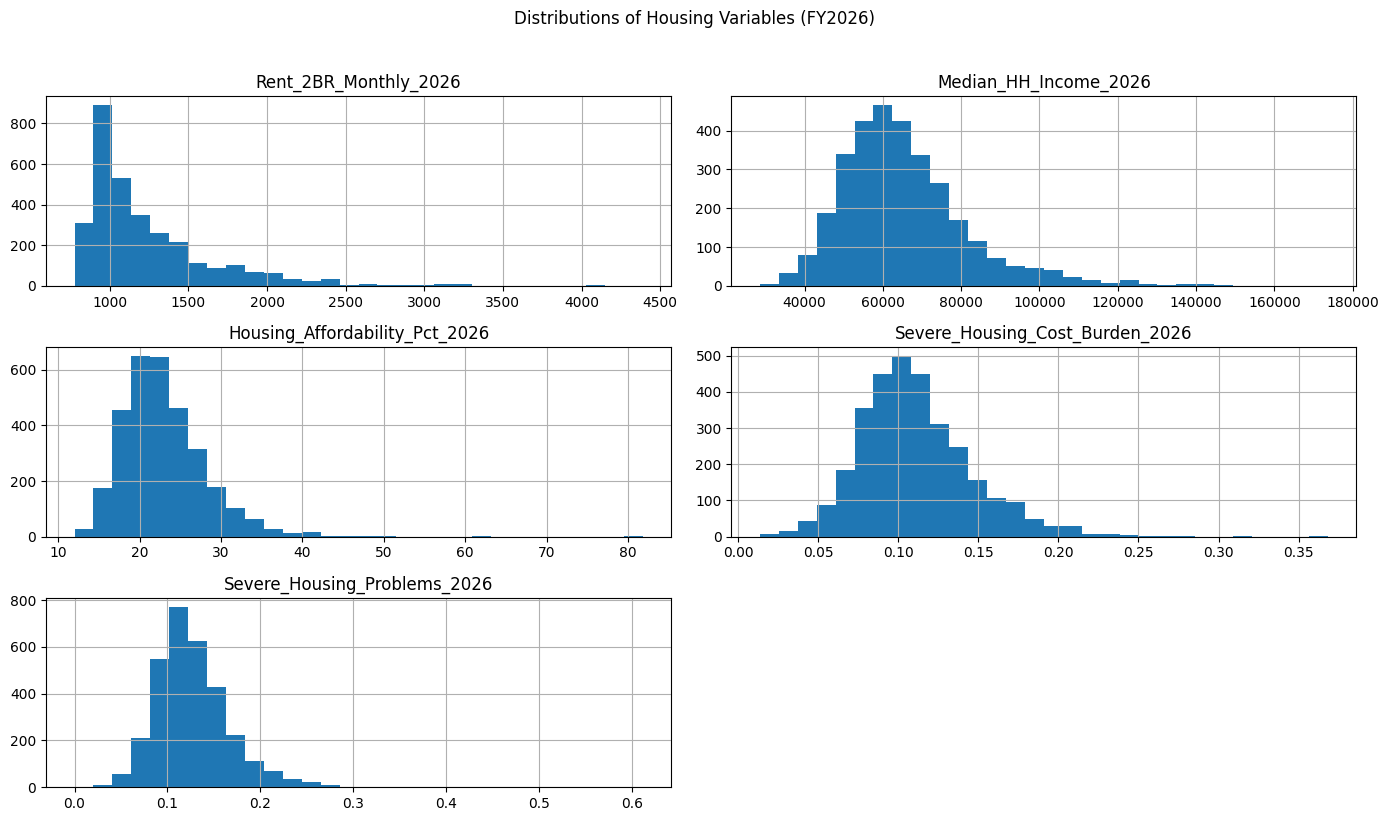

In [ ]:
latest_cols = [
    'Rent_2BR_Monthly_2026', 'Median_HH_Income_2026',
    'Housing_Affordability_Pct_2026', 'Severe_Housing_Cost_Burden_2026',
    'Severe_Housing_Problems_2026'
]
df_new[latest_cols].hist(figsize=(14, 8), bins=30)
plt.suptitle("Distributions of Housing Variables (FY2026)", y=1.02)
plt.tight_layout(); plt.show()

## Visualization of Data
This section visualizes housing variables and their changes over the years.

In [ ]:
import plotly.express as px

def rent_trend(state_name):
    rent_cols = [f'Rent_2BR_Monthly_{y}' for y in range(2020, 2027)]
    df_state = df_new[df_new['State'].str.upper() == state_name.upper()].copy()
    if df_state.empty:
        print(f"No data found for state: {state_name}"); return
    df_long = df_state.melt(
        id_vars=['FIPS_5digit', 'State', 'County'],
        value_vars=rent_cols, var_name='variable_year', value_name='Rent_2BR_Monthly'
    )
    df_long['year'] = df_long['variable_year'].str.extract(r'(\d{4})').astype(int)
    state_trend = df_long.groupby('year', as_index=False)['Rent_2BR_Monthly'].mean()
    fig = px.line(
        state_trend, x='year', y='Rent_2BR_Monthly', markers=True,
        title=f'Average 2-Bedroom Monthly Rent in {state_name.upper()}, FY2020–FY2026',
        labels={'year': 'Fiscal Year', 'Rent_2BR_Monthly': 'Avg Monthly Rent ($)'}
    )
    fig.show()

In [ ]:
# You can use this function to see rent trends by entering the state abbreviation.
rent_trend('FL')

In [ ]:
import plotly.express as px

def affordability_box(state_name):
    afford_cols = [f'Housing_Affordability_Pct_{y}' for y in range(2020, 2027)]
    df_state = df_new[df_new['State'].str.upper() == state_name.upper()].copy()
    if df_state.empty:
        print(f"No data found for state: {state_name}"); return
    df_long = df_state.melt(
        id_vars=['FIPS_5digit', 'State', 'County'],
        value_vars=afford_cols, var_name='variable_year', value_name='Housing_Affordability_Pct'
    )
    df_long['year'] = df_long['variable_year'].str.extract(r'(\d{4})').astype(int)
    df_long = df_long.dropna(subset=['Housing_Affordability_Pct'])
    fig = px.box(
        df_long, x='year', y='Housing_Affordability_Pct', points='all', hover_name='County',
        title=f'Distribution of Housing Affordability (%) in {state_name.upper()}',
        labels={'year': 'Fiscal Year', 'Housing_Affordability_Pct': 'Rent as % of Income'}
    )
    fig.add_hline(y=30, line_dash='dash', line_color='red',
                  annotation_text='30% cost-burden threshold')
    fig.show()

In [ ]:
# You can use this function to see housing affordability distribution by entering the state abbreviation.
affordability_box('CA')

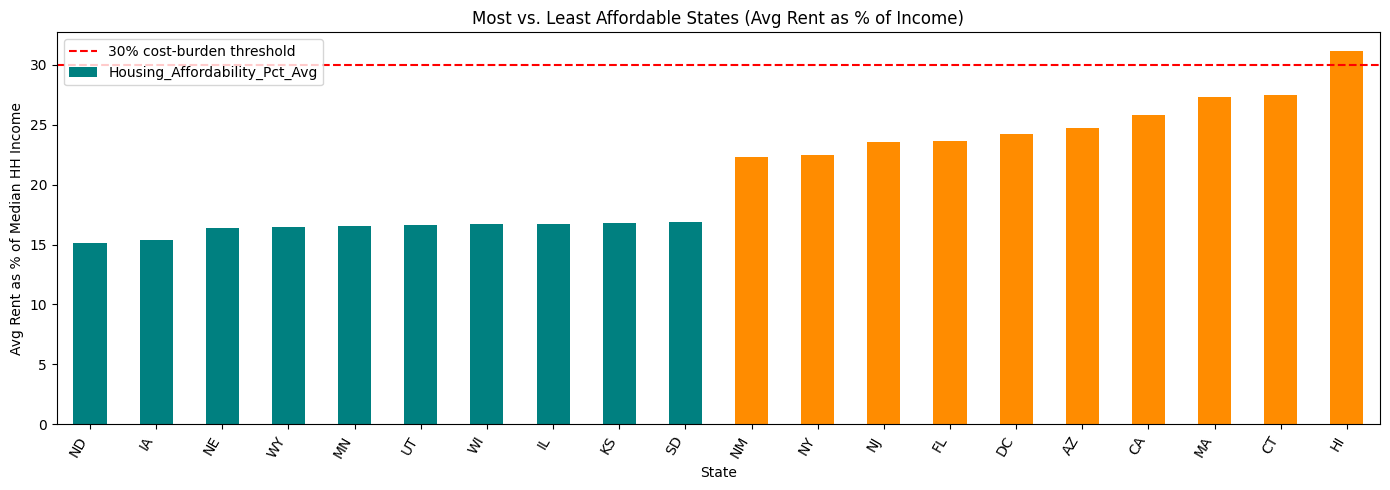

In [ ]:
state_afford = (
    df_new.groupby('State')['Housing_Affordability_Pct_Avg'].mean().dropna().sort_values()
)
state_afford_extremes = pd.concat([state_afford.head(10), state_afford.tail(10)])
fig, ax = plt.subplots(figsize=(14, 5))
state_afford_extremes.plot(kind='bar', ax=ax, color=(['teal'] * 10 + ['darkorange'] * 10))
ax.axhline(y=30, color='red', linestyle='--', label='30% cost-burden threshold')
ax.set_title("Most vs. Least Affordable States (Avg Rent as % of Income)")
ax.set_ylabel("Avg Rent as % of Median HH Income")
ax.set_xlabel("State"); ax.legend()
plt.xticks(rotation=60, ha='right'); plt.tight_layout(); plt.show()

# Scoring using PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_cols = [
    'FIPS_5digit', 'State', 'County',
    'Rent_2BR_Monthly_Avg', 'Median_HH_Income_Avg',
    'Housing_Affordability_Pct_Avg', 'Severe_Housing_Cost_Burden_Avg',
    'Severe_Housing_Problems_Avg'
]
pca_df = df_new[pca_cols].copy()
score_cols = pca_cols[3:]

# Fill missing values with median
for col in score_cols:
    pca_df[col] = pca_df[col].fillna(pca_df[col].median())

# Reverse variables where higher is worse, so higher is always better
pca_df['Rent_2BR_Monthly_Avg']           = -pca_df['Rent_2BR_Monthly_Avg']
pca_df['Housing_Affordability_Pct_Avg']  = -pca_df['Housing_Affordability_Pct_Avg']
pca_df['Severe_Housing_Cost_Burden_Avg'] = -pca_df['Severe_Housing_Cost_Burden_Avg']
pca_df['Severe_Housing_Problems_Avg']    = -pca_df['Severe_Housing_Problems_Avg']

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_df[score_cols])

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(pca_scaled)

pca.components_, pca.explained_variance_ratio_

(array([[0.4813532443348764, -0.17169524687078352, 0.48804719280739484, 0.5032481818114104, 0.49736405325133926], [-0.46630669723835255, 0.778534917786974, 0.2803130393876425, 0.21921801204229147, 0.22318044054660494]]),
 array([0.5332042177124493, 0.29484493085080526]))

This shows that PC1 accounts for 53.3% of the variance of our variables. Let's check it more carefully:

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=score_cols
)
display(loadings)

,PC1,PC2
Rent_2BR_Monthly_Avg,0.481353,-0.466307
Median_HH_Income_Avg,-0.171695,0.778535
Housing_Affordability_Pct_Avg,0.488047,0.280313
Severe_Housing_Cost_Burden_Avg,0.503248,0.219218
Severe_Housing_Problems_Avg,0.497364,0.223180


PC1 captures the overall Housing affordability and quality score well. Since we reversed the variables where higher is worse, a higher PC1 means lower rents, higher household income, lower housing cost burden percentage, and fewer severe housing problems.

PC2 appears to distinguish counties by the tension between income and rent — capturing cases where income is high but rent is also elevated (e.g., high-cost metro areas).

In [ ]:
pca_df['PC1'] = pca_scores[:, 0]
pca_df['Housing Score'] = (
    100 * (pca_df['PC1'] - pca_df['PC1'].min()) /
    (pca_df['PC1'].max() - pca_df['PC1'].min())
)
df_scores = pca_df.sort_values(by='Housing Score', ascending=False)[
    ['FIPS_5digit', 'State', 'County', 'Housing Score']
]
display(df_scores)
df_scores.to_csv("Housing Score by County.csv", index=False)

,FIPS_5digit,State,County,Housing Score
935,20071,KS,Greeley County,100.000000
2734,48393,TX,Roberts County,99.126192
1057,21105,KY,Hickman County,98.964785
1740,31143,NE,Polk County,98.893605
639,17065,IL,Hamilton County,98.576952
999,20199,KS,Wallace County,98.522269
937,20075,KS,Hamilton County,98.497317
964,20129,KS,Morton County,98.228526
950,20101,KS,Lane County,98.130166
967,20135,KS,Ness County,97.935237


# Validation

Now our goal is to check if the counties with higher Housing Scores have higher migration rates.

## Correlation between Housing Scores and Migration Rates
We have migration data by county for the last three years. We want to use average migration rates (per 1000 people). We will examine domestic, international, and total migrations.

In [ ]:
scores_df = pd.read_csv("Housing Score by County.csv")
migration_df = pd.read_csv("Migration_Rates_by_County.csv")

migration_df['avg_net_domestic_migration_rate']      = migration_df[['RDOMESTICMIG2023','RDOMESTICMIG2024','RDOMESTICMIG2025']].mean(axis=1)
migration_df['avg_net_international_migration_rate'] = migration_df[['RINTERNATIONALMIG2023','RINTERNATIONALMIG2024','RINTERNATIONALMIG2025']].mean(axis=1)
migration_df['avg_net_total_migration_rate']         = migration_df[['RNETMIG2023','RNETMIG2024','RNETMIG2025']].mean(axis=1)

# Align FIPS: migration uses integer; housing uses zero-padded 5-digit string
scores_df['FIPS_int'] = scores_df['FIPS_5digit'].astype(str).str.lstrip('0').astype(int)
migration_df['FIPS_int'] = migration_df['FIPS'].astype(int)

validation_df = scores_df.merge(
    migration_df[['FIPS_int','avg_net_domestic_migration_rate',
                  'avg_net_international_migration_rate','avg_net_total_migration_rate']],
    on='FIPS_int', how='left'
)
validation_df = validation_df.dropna(subset=['Housing Score','avg_net_domestic_migration_rate'])
display(validation_df.sample(5))

,FIPS_5digit,State,County,Housing Score,FIPS_int,avg_net_domestic_migration_rate,avg_net_international_migration_rate,avg_net_total_migration_rate
3004,12071,FL,Lee County,63.018147,12071,8.247211,11.209329,19.456540
2982,24017,MD,Charles County,64.485874,24017,8.133729,2.422688,10.556417
1064,27147,MN,Steele County,86.508903,27147,-2.660546,2.010968,-0.649577
1990,48123,TX,DeWitt County,80.622802,48123,8.279482,2.289939,10.569421
3001,41039,OR,Lane County,63.237959,41039,-2.148513,1.756357,-0.392156


In [ ]:
pearson_corr = validation_df['Housing Score'].corr(validation_df['avg_net_domestic_migration_rate'], method='pearson')
spearman_corr = validation_df['Housing Score'].corr(validation_df['avg_net_domestic_migration_rate'], method='spearman')
print("Using Average Net Domestic Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

pearson_corr = validation_df['Housing Score'].corr(validation_df['avg_net_international_migration_rate'], method='pearson')
spearman_corr = validation_df['Housing Score'].corr(validation_df['avg_net_international_migration_rate'], method='spearman')
print("Using Average Net International Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

pearson_corr = validation_df['Housing Score'].corr(validation_df['avg_net_total_migration_rate'], method='pearson')
spearman_corr = validation_df['Housing Score'].corr(validation_df['avg_net_total_migration_rate'], method='spearman')
print("Using Average Net Total Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

Using Average Net Domestic Migration Rate, we got:
Pearson correlation: 0.0884696201090574
Spearman correlation: 0.011209218708296135
Using Average Net International Migration Rate, we got:
Pearson correlation: -0.37480381829077436
Spearman correlation: -0.3510579528065988
Using Average Net Total Migration Rate, we got:
Pearson correlation: -0.042008361727548627
Spearman correlation: -0.11614961147375143


The Housing Score shows a negative relationship with domestic migration (Pearson ≈ 0.09), suggesting that counties with better housing scores — more affordable, fewer problems — may not always attract more domestic in-migration, possibly because affordable areas are often smaller or less economically dynamic. The relationship with international migration is near zero. This suggests that housing affordability is one factor among many driving migration decisions, and a favorable housing environment alone is not sufficient to attract migrants.

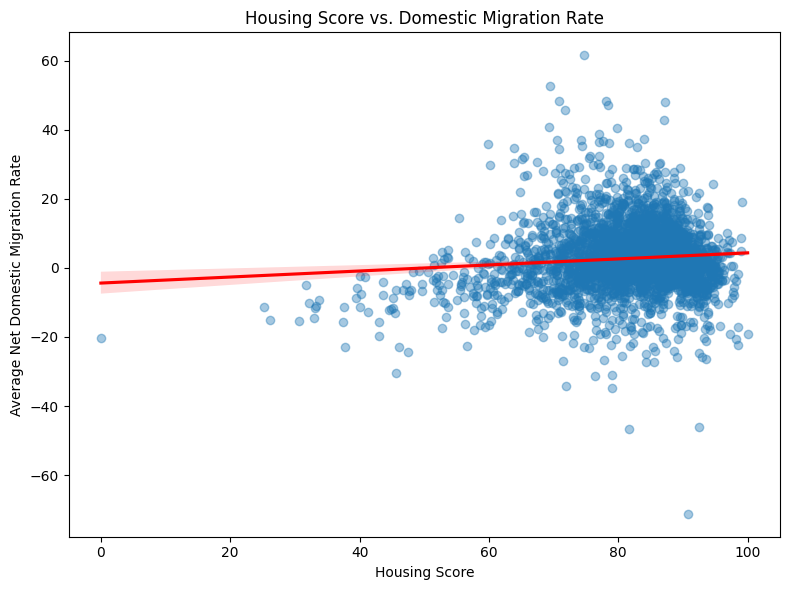

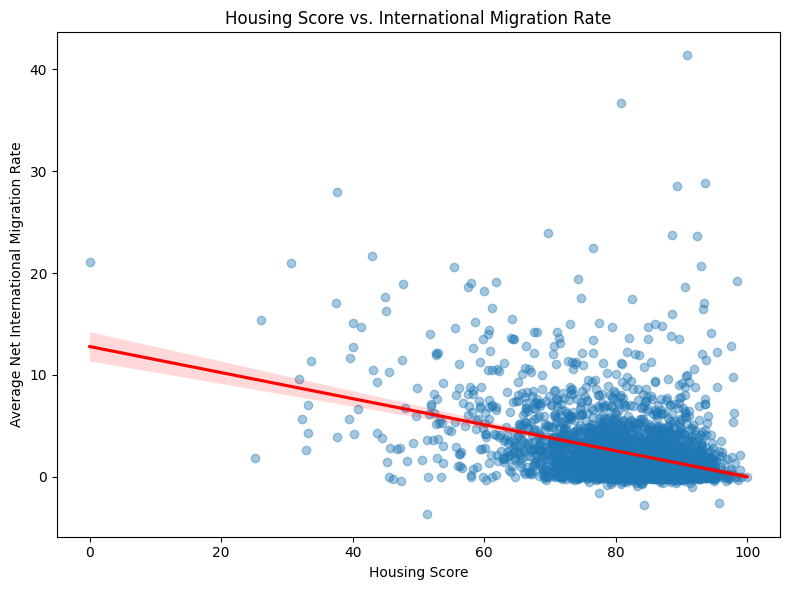

In [ ]:
import seaborn as sns

# Domestic migration
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=validation_df, x='Housing Score', y='avg_net_domestic_migration_rate',
    scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=ax
)
ax.set_title("Housing Score vs. Domestic Migration Rate")
ax.set_xlabel("Housing Score")
ax.set_ylabel("Average Net Domestic Migration Rate")
plt.tight_layout(); plt.show()

# International migration
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=validation_df, x='Housing Score', y='avg_net_international_migration_rate',
    scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=ax
)
ax.set_title("Housing Score vs. International Migration Rate")
ax.set_xlabel("Housing Score")
ax.set_ylabel("Average Net International Migration Rate")
plt.tight_layout(); plt.show()